# DiSCount: automated counting of Striga seed germination — Colab reproduction

Reproduction of the inference pipeline from:

> Masteling R., Voorhoeve L., IJsselmuiden J., Dini-Andreote F., de Boer W., Raaijmakers J.M. **DiSCount: computer vision for automated quantification of Striga seed germination.** *Plant Methods* 2020;16:60. DOI: [10.1186/s13007-020-00602-8](https://doi.org/10.1186/s13007-020-00602-8)

DiSCount detects **seeds** and **radicle onsets** of *Striga hermonthica* on glass-fibre filter assay images with a YOLOv3 network (PyTorch), writes an annotated image, and reports counts and the germination fraction (radicles / seeds) in a CSV.

**Scope of this notebook (partial demonstration):** the authors' own pinned inference code (`discount_paper` @ GitLab commit `417b4dcd`, MIT) is run **unchanged** on **one** author-designated test image (Zenodo record 3404131, the record the authors supplied "to test the DiSCount installation") using the paper's epoch-9000 weights at 608×608 with the paper's threshold P = 0.06.

**Not in scope:** training (20,000 batches in Darknet), dataset-level testing over the 94 held-out images, the manual Photoshop "Photomerge" step that produces merged filter images, and the GUI distribution packaging. A single-image run does **not** verify the paper's dataset-level accuracy (average test error 3.38 percentage points over 94 images).

**状態:** 実行済みの部分的再現デモです。著者自身の推論コードをそのまま実行し、著者が公開したテスト用画像 1 枚に論文の学習済み重み（epoch 9000, 閾値 P=0.06, 608×608）を適用します。学習・データセット全体の検証・画像マージ処理は対象外です。

## Runtime selection & how to run

**Recommended runtime: CPU** (menu: Runtime → Change runtime type → *CPU*). The paper's tool was designed for CPU-only lab PCs (~3 s/image on the authors' hardware); CPU is the faithful default here. A **T4 GPU** runtime also works: the author code auto-detects CUDA and needs ~2 GB of GPU memory — inference is simply faster.

Then **Runtime → Run all**.

Downloads performed by this notebook (~260 MB total, all inside Colab):

| Item | Source | Size |
| --- | --- | --- |
| YOLOv3 weights `nioo_15-05-2019_608_9000.weights` | GitLab `lodewijk-track32/discount_paper` @ `417b4dcd` (MIT) | ≈246 MB |
| Test image `series1_27-1.png` | Zenodo record [3404131](https://zenodo.org/records/3404131) (CC-BY-4.0) | 8.5 MB |
| Author code files (8 small text files) | same GitLab commit | <100 KB |

Expected wall time: ~5–15 min depending on runtime (dominated by the weights download and one YOLOv3 forward pass).

**実行方法:** 「ランタイム」→「ランタイムのタイプを変更」で CPU（推奨）または T4 GPU を選び、「ランタイム」→「すべてのセルを実行」です。合計約 260 MB のダウンロードと 1 枚の推論で、数分〜十数分で完了します。

In [ ]:
import sys, platform
print("Python:", sys.version.split()[0], "|", platform.platform())
import torch, cv2, numpy, pandas, matplotlib
print("torch:", torch.__version__)
print("opencv:", cv2.__version__)
print("numpy:", numpy.__version__, "| pandas:", pandas.__version__, "| matplotlib:", matplotlib.__version__)
CUDA = torch.cuda.is_available()
print("CUDA available:", CUDA)
if CUDA:
    print("GPU:", torch.cuda.get_device_name(0))
# The author script sets torch.set_num_threads(4) and enables CUDA automatically
# when available (DISCount.py lines 38-42, 66-69, 86-87). Both runtimes are faithful.

Python: 3.13.15 | Linux-6.6.122+-x86_64-with-glibc2.39


torch: 2.11.0+cpu
opencv: 4.14.0
numpy: 2.1.3 | pandas: 2.2.3 | matplotlib: 3.10.0
CUDA available: False


## Setup: fetch the authors' pinned code (GitLab commit `417b4dcd`)

The authors' repository [lodewijk-track32/discount_paper](https://gitlab.com/lodewijk-track32/discount_paper) (MIT license, head commit `417b4dcd756e48e123cb1bb351ba858ccef607fd`, 2021-11-02, "Update due to new version of PyTorch (1.10) and OpenCV (4.5.4)") contains the complete tool. We download the eight code/config text files individually from that **exact commit** into `/content/DISCount`, preserving the authors' layout (`config/`, `data/`). Nothing in these files is modified; `DISCount.py` will be executed verbatim later.

- `DISCount.py` — main inference script (thresholds, counting, CSV + annotated output)
- `darknet.py` — YOLOv3 `Darknet` model and weight loader (based on Ayoosh Kathuria's pytorch-yolo-v3)
- `util.py` — post-processing (`write_results` NMS/threshold), `load_classes`
- `preprocess.py` — `prep_image` letterbox resize to 608×608
- `bbox.py` — bbox helper module (imported by the tool package)
- `config/nioo.data`, `config/nioo_15-05-2019_608.cfg` — Darknet config (608×608, 2 classes)
- `data/nioo.names` — class names: `Seed`, `Radicle`

**コード取得:** 著者の GitLab リポジトリから、ピン留めしたコミット `417b4dcd` のコードと設定ファイルをそのまま Colab 内にダウンロードします（MIT ライセンス）。ファイルは変更しません。

In [ ]:
import hashlib, pathlib, urllib.request

PIN = "417b4dcd756e48e123cb1bb351ba858ccef607fd"
REPO_RAW = f"https://gitlab.com/lodewijk-track32/discount_paper/-/raw/{PIN}"
CODE_FILES = [
    "DISCount.py", "darknet.py", "util.py", "preprocess.py", "bbox.py",
    "config/nioo.data", "config/nioo_15-05-2019_608.cfg", "data/nioo.names",
]
for rel in CODE_FILES:
    dest = pathlib.Path("/content/DISCount") / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(f"{REPO_RAW}/{rel}", timeout=60) as r:
        data = r.read()
    dest.write_bytes(data)
    print(f"{rel:32s} {len(data):>7d} B  sha256={hashlib.sha256(data).hexdigest()[:16]}")
print("Author code fetched at pinned commit", PIN)

DISCount.py                         8804 B  sha256=5d3b0f44f5af6808


darknet.py                         15891 B  sha256=d0cf7a2de39c2022


util.py                            12987 B  sha256=d98edfb79b515501
preprocess.py                       1909 B  sha256=4ab97f4f56dc300e


bbox.py                             3266 B  sha256=111fa574abdefea2


config/nioo.data                     124 B  sha256=1fe44459485cb067


config/nioo_15-05-2019_608.cfg      8278 B  sha256=6a150182e9e91c75


data/nioo.names                       13 B  sha256=5f0b08691c01ea2c
Author code fetched at pinned commit 417b4dcd756e48e123cb1bb351ba858ccef607fd


## Minimal input & trained weights (with provenance and checksums)

**Weights** — the paper's epoch-9000 YOLOv3 model at 608×608 resolution:
`config/nioo_15-05-2019_608_9000.weights` from the same pinned commit (≈246 MB). GitLab's files-API returns 404 for this large binary, so the notebook downloads the web raw URL and falls back to GitLab's blobs API (base64 JSON) if needed. Darknet weight files start with an int32 header (major, minor, revision, images-seen); we check a plausible size and header before use.

**Test input** — `series1_27-1.png` from Zenodo record [3404131](https://zenodo.org/records/3404131) ("Input files to test the DiSCount installation – Masteling et al.", CC-BY-4.0): a merged filter-assay image (~2500×2500 px). The download goes through the record API's returned content link, and the file's md5 (`db7560fd2acf17f6a0625a33829bb7d1`) and size (8,523,631 B) listed in the record are verified before use.

**重みとテスト画像の取得:** 論文の epoch-9000 重み（約 246 MB）と、著者が動作確認用に公開した Zenodo レコード 3404131 のテスト画像（8.5 MB）を Colab 内でダウンロードし、チェックサムを検証します。

In [ ]:
import base64, json, hashlib, io, pathlib, urllib.request

weights_path = pathlib.Path("/content/DISCount/config/nioo_15-05-2019_608_9000.weights")
if not weights_path.exists():
    try:
        url = f"{REPO_RAW}/config/nioo_15-05-2019_608_9000.weights"
        print("Downloading weights (web raw URL, ~246 MB) ...")
        with urllib.request.urlopen(url, timeout=600) as r:
            data = r.read()
        print("  got", len(data), "bytes from raw URL")
    except Exception as e:
        print("  raw URL failed:", e)
        print("  falling back to GitLab blobs API (base64 JSON) ...")
        blob_api = ("https://gitlab.com/api/v4/projects/lodewijk-track32%2Fdiscount_paper"
                    "/repository/blobs/70b6e7b82400a7990f2b0cee43c9b4a54db40065")
        with urllib.request.urlopen(blob_api, timeout=900) as r:
            doc = json.loads(r.read())
        data = base64.b64decode(doc["content"])
        print("  got", len(data), "bytes from blobs API")
    weights_path.write_bytes(data)
print("weights size on disk:", weights_path.stat().st_size, "bytes")
assert weights_path.stat().st_size > 200_000_000, "weights file implausibly small"
with open(weights_path, "rb") as fh:
    header = fh.read(16)
print("weights sha256:", hashlib.sha256(weights_path.read_bytes()).hexdigest())
print("first int32 header fields (major, minor, revision, seen):",
      list(__import__("struct").unpack("<4i", header)))

# --- Zenodo test image via the record API's returned content link ---
rec = json.loads(urllib.request.urlopen(
    "https://zenodo.org/api/records/3404131", timeout=60).read())
print("record:", rec["metadata"]["title"], "| license:", rec["metadata"]["license"]["id"])
f = next(f for f in rec["files"] if f["key"] == "series1_27-1.png")
print("file:", f["key"], "size:", f["size"], "checksum:", f["checksum"])
with urllib.request.urlopen(f["links"]["self"], timeout=300) as r:
    img_bytes = r.read()
md5 = hashlib.md5(img_bytes).hexdigest()
assert md5 == "db7560fd2acf17f6a0625a33829bb7d1", f"md5 mismatch: {md5}"
assert len(img_bytes) == f["size"], "size mismatch"
print("md5 verified OK:", md5)
pathlib.Path("/content/input").mkdir(exist_ok=True)
pathlib.Path("/content/input/series1_27-1.png").write_bytes(img_bytes)
pathlib.Path("/content/evaluated").mkdir(exist_ok=True)
print("saved to /content/input/series1_27-1.png")

  got 246326924 bytes from raw URL


weights size on disk: 246326924 bytes


weights sha256: ac0ba201e1584e2e7caf3004969fac479388b6935b0be3831d711225a2937002
first int32 header fields (major, minor, revision, seen): [0, 1, 0, 288000]


record: Input files to test the DiSCount installation - Masteling et al | license: cc-by-4.0
file: series1_27-1.png size: 8523631 checksum: md5:db7560fd2acf17f6a0625a33829bb7d1


md5 verified OK: db7560fd2acf17f6a0625a33829bb7d1
saved to /content/input/series1_27-1.png


**Input preview.** The test image is displayed (downsampled) to confirm the downloaded bytes are a valid merged filter-assay PNG before inference.

**入力画像の確認:** ダウンロードした画像が正しい PNG か確認のため、縮小プレビューを表示します。

input image shape (H, W, C): (2514, 2617, 3)


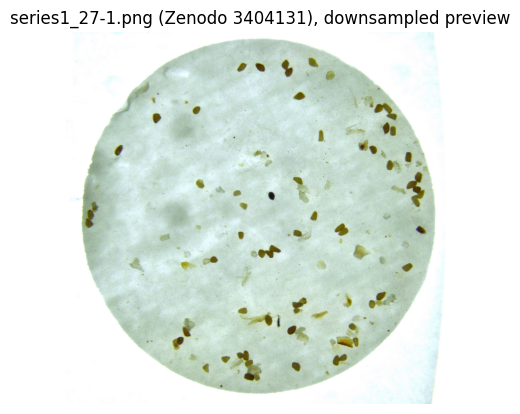

In [ ]:
import cv2, matplotlib.pyplot as plt
im = cv2.imread("/content/input/series1_27-1.png")
print("input image shape (H, W, C):", im.shape)
small = cv2.resize(im, (im.shape[1] // 4, im.shape[0] // 4))
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
plt.title("series1_27-1.png (Zenodo 3404131), downsampled preview")
plt.axis("off")
plt.show()

## Run the authors' DiSCount inference script on the test image

`DISCount.py` is executed **verbatim** (no edits) as a subprocess with working directory `/content/DISCount`, matching the authors' expected layout: images in `../input`, annotated outputs in `../evaluated`. Its own constants provide the paper's settings: `confidence = 0.06` and `nms_thesh = 0.06` (threshold P = 0.06 from the paper's Model evaluation section), resolution 608 (`model.net_info["height"] = 608`, tuned anchors), 2 classes (`Seed`, `Radicle`). The script prints per-image counts, writes `evaluation.csv` (columns: image name, Seed count, Radicle count, germination fraction = Radicle/Seed) and saves the annotated image. On a CUDA runtime the script switches to the GPU automatically; on CPU it uses 4 torch threads.

**推論の実行:** 著者の `DISCount.py` を一切変更せず、著者の想定するディレクトリ構成のまま Colab 内で実行します。閾値 P=0.06・608×608・2 クラス（Seed / Radicle）はすべて著者コード内の設定値です。GPU があれば自動で CUDA を使用します。

In [ ]:
import os, subprocess, sys, time

t0 = time.time()
result = subprocess.run(
    [sys.executable, "DISCount.py"],
    cwd="/content/DISCount",
    capture_output=True, text=True, timeout=3600,  # short run (~8 s); output echoed below
)
print(result.stdout, end="")
if result.stderr:
    print("[stderr]", result.stderr, end="")
wall = time.time() - t0
print(f"DISCount.py exit code: {result.returncode}  |  wall time: {wall:.1f} s")
assert result.returncode == 0, "author script failed"

Using CUDA:  False
Loading DISCount weights file
Network successfully loaded
Using resolution:  608
Number: 1
series1_27-1.png     predicted in   3.01 seconds
Seeds: 52, Radicles: 1, Germination Percentage: 1.92
----------------------------------------------------------

Results
----------------------------------------------------------
Evaluation of input results stored in 'evaluation.csv' file
Images with detections stored in the 'evaluated' folder

Task                     : Time Taken (in seconds)

Detection (1 images)     : 3.026
Saving annotations       : 0.350
Average time_per_img     : 3.660
----------------------------------------------------------
DISCount.py exit code: 0  |  wall time: 8.2 s


**Tool's own CSV output.** `evaluation.csv` as written by the authors' script (image name, Seed count, Radicle count, germination fraction).

**ツール出力の CSV:** 著者スクリプトが書き出した `evaluation.csv` の内容を表示します。

In [ ]:
import csv
with open("/content/DISCount/evaluation.csv") as fh:
    rows = list(csv.reader(fh))
print("evaluation.csv contents:")
for row in rows:
    print(" ", row)

evaluation.csv contents:
  ['series1_27-1.png', '52', '1', '0.0192']


## Results: annotated image and germination table

The tool's annotated output (`../evaluated/series1_27-1.png`) draws **Seed** boxes in magenta and **Radicle** boxes in green, as in the paper's Fig. 2-style output. Below, the original input and the annotated output are shown side by side, followed by the counts and the germination fraction (Radicle / Seed, shown both as the authors' code reports it and as a percentage, which is the paper's "germination rate").

This is one author-provided test image, not a hand-counted ground-truth sample, so no paper-accuracy claim is made from this run.

**結果の表示:** 左に入力画像、右に検出結果（Seed=マゼンタ、Radicle=緑のバウンディングボックス）を並べて表示し、カウントと発芽率（Radicle/Seed）を表にします。

annotated output shape: (2514, 2617, 3) (saved by the tool to ../evaluated)


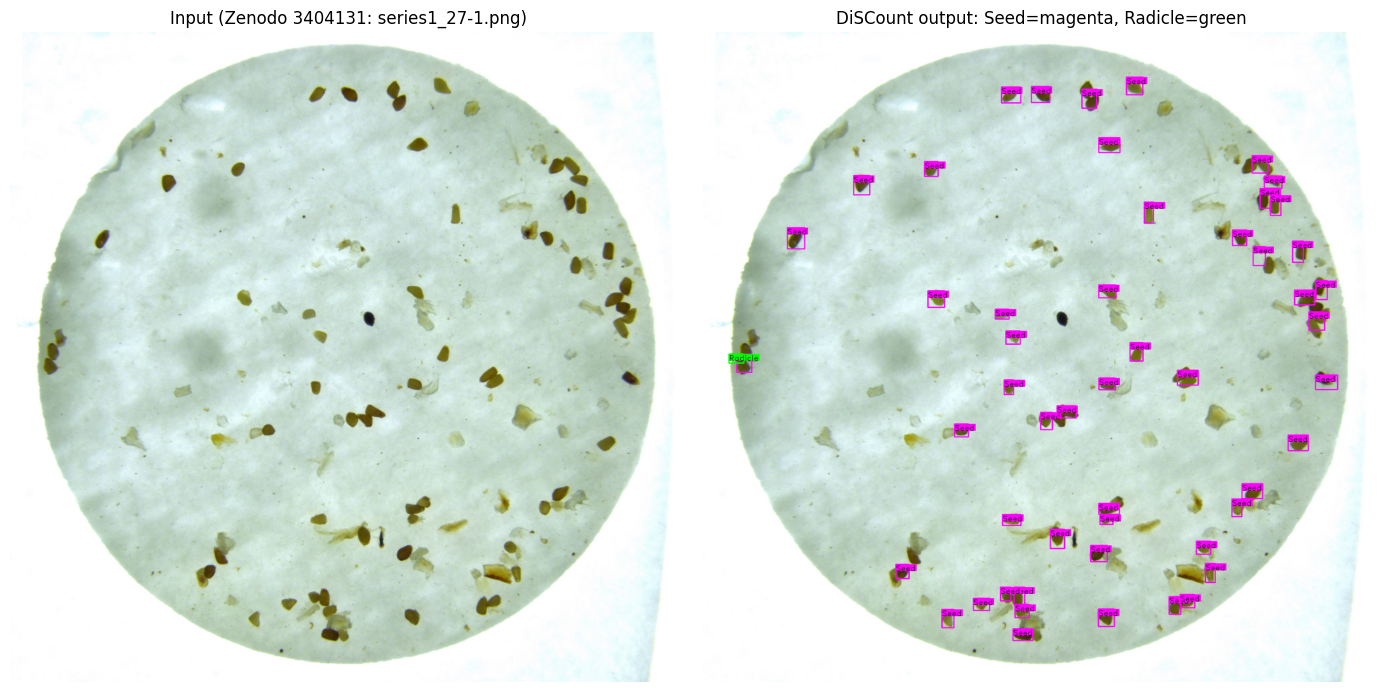

Counts and germination (authors' metric = Radicle / Seed; % = fraction x 100):


,image,Seed,Radicle,germination_fraction,germination_percent
0,series1_27-1.png,52,1,0.0192,1.92


Device used by the run:  CPU


In [ ]:
import cv2, pandas as pd, matplotlib.pyplot as plt

orig = cv2.imread("/content/input/series1_27-1.png")
annot = cv2.imread("/content/evaluated/series1_27-1.png")
print("annotated output shape:", annot.shape, "(saved by the tool to ../evaluated)")

# side-by-side downsampled view
h, w = orig.shape[:2]
sc = 1400.0 / w
orig_s = cv2.resize(orig, (1400, int(h * sc)))
annot_s = cv2.resize(annot, (1400, int(h * sc)))
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(orig_s, cv2.COLOR_BGR2RGB)); axes[0].set_title("Input (Zenodo 3404131: series1_27-1.png)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(annot_s, cv2.COLOR_BGR2RGB)); axes[1].set_title("DiSCount output: Seed=magenta, Radicle=green"); axes[1].axis("off")
plt.tight_layout(); plt.show()

tab = pd.read_csv("/content/DISCount/evaluation.csv",
                  names=["image", "Seed", "Radicle", "germination_fraction"])
tab["germination_percent"] = (tab["germination_fraction"] * 100).round(2)
print("Counts and germination (authors' metric = Radicle / Seed; % = fraction x 100):")
display(tab)  # noqa: F821 (Colab builtin)
print("Device used by the run: ", "CUDA GPU" if __import__("torch").cuda.is_available() else "CPU")

## Interpretation, limitations, and validation record

**What this demonstrates.** The authors' complete DiSCount inference pipeline — YOLOv3 (PyTorch port), letterbox preprocessing to 608×608, the paper's epoch-9000 weights, threshold P = 0.06, NMS, per-image counting of Seeds and Radicles, the germination fraction, the annotated image, and `evaluation.csv` — runs end-to-end in Colab on one author-designated test image.

**Limitations.**
- A single test image; the paper's reported accuracy (3.38 percentage-point average germination error on 94 held-out hand-counted images; ~80% of test images within 0–5% error) is **not** verified here. The Zenodo test-input record provides no hand counts.
- Training, the full testing dataset (Zenodo record 3403956), and the manual Photoshop "Photomerge" step are out of scope.
- CPU vs GPU: the script auto-detects CUDA; both runtimes use identical weights, preprocessing, and thresholds (minor floating-point variation possible).
- The germination fraction can be undefined if zero seeds are detected (the authors' code would divide by zero on such images); the authors' test input contains seeds.

**Validation record.** This notebook was executed top-to-bottom in a fresh Colab session; see the companion report and the archived executed output for the runtime, date, and measured timings of each validation run.

**要点:** 著者の推論パイプライン（前処理・重み・閾値・NMS・計数・CSV 出力）を 1 枚のテスト画像で再現しました。単一画像の実行は論文のデータセット精度（平均誤差 3.38 ポイント）の検証にはならず、学習・全テストセット・画像マージは対象外です。

## References and provenance

- **Paper:** Masteling et al., *Plant Methods* 2020;16:60, DOI [10.1186/s13007-020-00602-8](https://doi.org/10.1186/s13007-020-00602-8) (publisher version of record, PMC7195706).
- **Code:** GitLab [lodewijk-track32/discount_paper](https://gitlab.com/lodewijk-track32/discount_paper), commit `417b4dcd756e48e123cb1bb351ba858ccef607fd` (2021-11-02), MIT License. Model code based on Ayoosh Kathuria's [pytorch-yolo-v3](https://github.com/ayooshkathuria/pytorch-yolo-v3).
- **Weights:** `config/nioo_15-05-2019_608_9000.weights` from the same commit (paper's selected epoch 9000, 608×608).
- **Test input:** Zenodo record [3404131](https://zenodo.org/records/3404131), file `series1_27-1.png`, md5 `db7560fd2acf17f6a0625a33829bb7d1`, CC-BY-4.0.
- **Full testing dataset (not run here):** Zenodo record [3403956](https://zenodo.org/records/3403956), CC-BY-4.0.
- PhenoPaper investigation `p-970513dc011c14d8207ae3d9cf35b642-20260929T125710Z-2630224` was used as prior research guidance; all parameters above were verified against the pinned author code and config.

**出典:** 論文・著者コード（GitLab コミット `417b4dcd`、MIT）・重み・テスト画像（Zenodo 3404131、CC-BY-4.0）の由来を記載しています。